# Notebook 14: Visualization for the Selected 7-Fold Workflow

This notebook generates the report and presentation figures that support the final validation choice from Notebook 13.

The focus here is no longer a generic experiment summary. Instead, the notebook visualizes the selected **7-fold cross-validation workflow** and its associated final XGBoost artifacts. The exported filenames follow the figure list used in the report outline for the six model-result figures generated directly from project artifacts.


14_visualization: Generate figures for the selected 7-fold workflow
Log directory: C:\Users\LENOVO\Desktop\machinelearning_project\logs
Figure directory: C:\Users\LENOVO\Desktop\machinelearning_project\figures

Loaded 7-fold artifacts:
- Fold AUCs: [0.7259607017518144, 0.7242820168772737, 0.725152857752661, 0.7267482782564978, 0.7259114989066395]
- Mean AUC: 0.725611
- Std AUC: 0.000835
- OOF AUC: 0.725604
- Number of folds: 5

1. Generating 7-fold CV AUC bar chart...


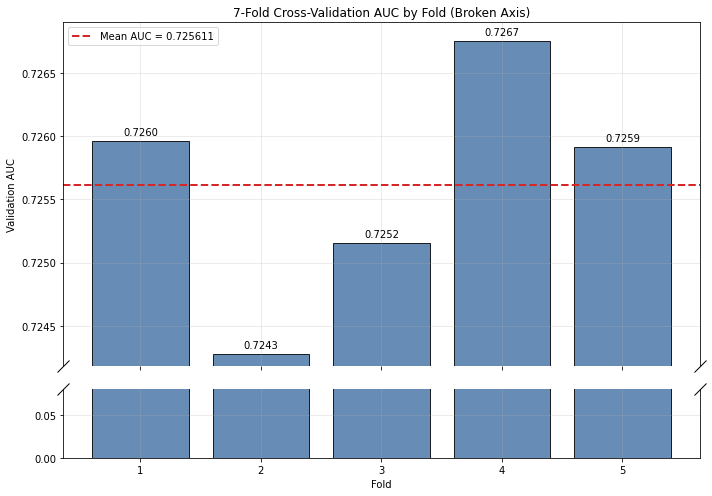


2. Generating Top 15 feature importance chart...


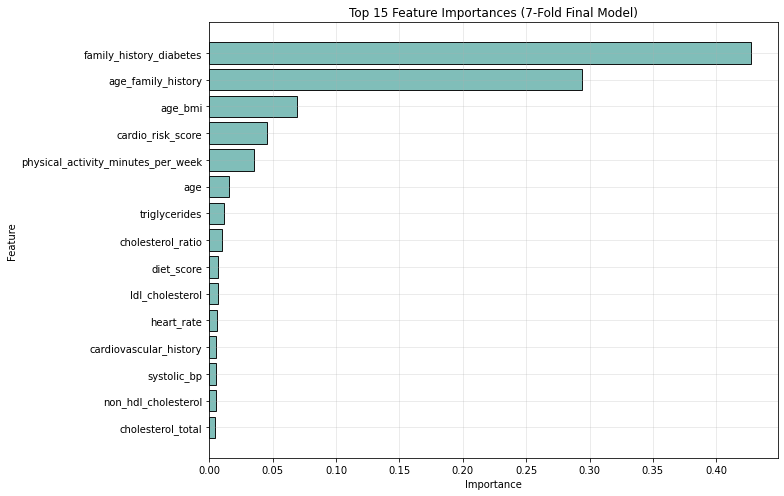


3. Generating Top 5 feature importance pie chart...


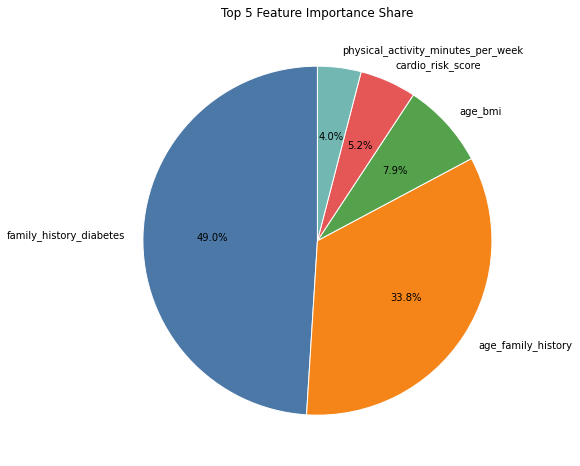


4. Generating ROC curve...


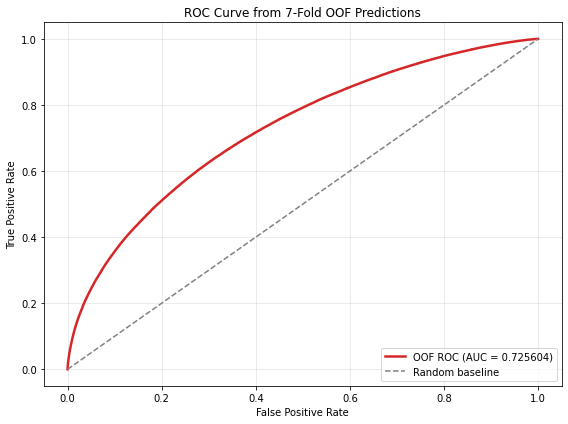


5. Generating prediction distribution chart...


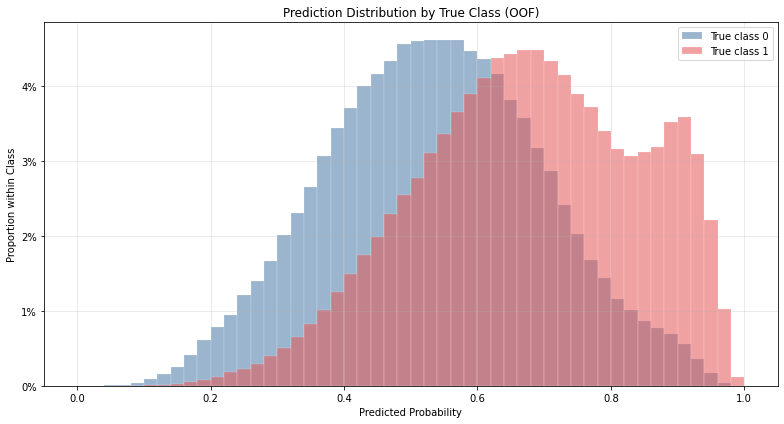


6. Generating fold AUC boxplot...


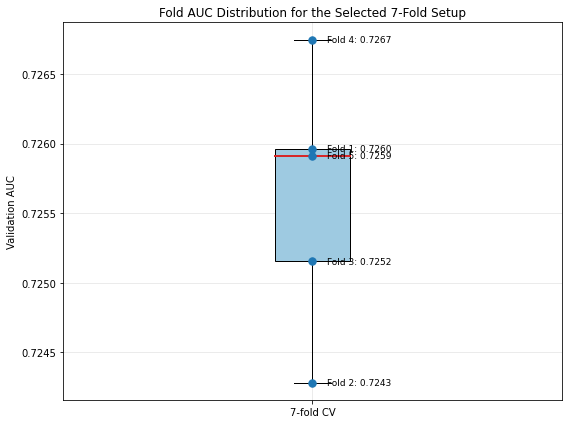


Generated figure files:
- figure_1: C:\Users\LENOVO\Desktop\machinelearning_project\figures\figure_1_7fold_cv_aucs.png
- figure_2: C:\Users\LENOVO\Desktop\machinelearning_project\figures\figure_2_feature_importance.png
- figure_3: C:\Users\LENOVO\Desktop\machinelearning_project\figures\figure_3_feature_importance_pie.png
- figure_4: C:\Users\LENOVO\Desktop\machinelearning_project\figures\figure_4_roc_curve.png
- figure_5: C:\Users\LENOVO\Desktop\machinelearning_project\figures\figure_5_prediction_distribution.png
- figure_6: C:\Users\LENOVO\Desktop\machinelearning_project\figures\figure_6_auc_boxplot.png


In [1]:
# 14_visualization.ipynb
# Generate report figures for the selected 7-fold workflow

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve, auc

plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print('=' * 60)
print('14_visualization: Generate figures for the selected 7-fold workflow')
print('=' * 60)

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == 'notebooks' else CURRENT_DIR
LOG_DIR = PROJECT_ROOT / 'logs'
FIGURE_DIR = PROJECT_ROOT / 'figures'

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print(f'Log directory: {LOG_DIR}')
print(f'Figure directory: {FIGURE_DIR}')

summary_path = LOG_DIR / 'summary.json'
feature_imp_path = LOG_DIR / 'feature_importance.csv'
oof_path = LOG_DIR / 'oof_predictions.csv'

required_paths = [summary_path, feature_imp_path, oof_path]
missing = [str(p) for p in required_paths if not p.exists()]
if missing:
    raise FileNotFoundError('Missing required 7-fold artifacts: ' + ', '.join(missing))

with open(summary_path, 'r', encoding='utf-8') as f:
    summary = json.load(f)

feature_importance = pd.read_csv(feature_imp_path)
oof_df = pd.read_csv(
    oof_path,
    usecols=['y_true', 'y_pred'],
    dtype={'y_true': 'uint8', 'y_pred': 'float32'},
)

fold_count = summary.get('n_splits', summary.get('N_splits'))
if fold_count is None:
    fold_aucs_from_summary = summary.get('fold_aucs')
    if fold_aucs_from_summary is not None:
        fold_count = len(fold_aucs_from_summary)
    else:
        raise KeyError("summary.json must contain fold information via 'n_splits', 'N_splits', or 'fold_aucs'")

print('\nLoaded 7-fold artifacts:')
print(f"- Fold AUCs: {summary['fold_aucs']}")
print(f"- Mean AUC: {summary['mean_fold_auc']:.6f}")
print(f"- Std AUC: {summary['std_fold_auc']:.6f}")
print(f"- OOF AUC: {summary['oof_auc']:.6f}")
print(f"- Number of folds: {fold_count}")

fold_aucs = summary['fold_aucs']
mean_auc = summary['mean_fold_auc']
std_auc = summary['std_fold_auc']
oof_auc = summary['oof_auc']

figure_paths = {
    'figure_1': FIGURE_DIR / 'figure_1_7fold_cv_aucs.png',
    'figure_2': FIGURE_DIR / 'figure_2_feature_importance.png',
    'figure_3': FIGURE_DIR / 'figure_3_feature_importance_pie.png',
    'figure_4': FIGURE_DIR / 'figure_4_roc_curve.png',
    'figure_5': FIGURE_DIR / 'figure_5_prediction_distribution.png',
    'figure_6': FIGURE_DIR / 'figure_6_auc_boxplot.png',
}

# ============================================================
# Figure 1: 7-fold CV AUCs
# ============================================================
print('\n1. Generating 7-fold CV AUC bar chart...')
fig, (ax_top, ax_bottom) = plt.subplots(
    2,
    1,
    sharex=True,
    figsize=(10, 7),
    gridspec_kw={'height_ratios': [5, 1]},
)
fold_ids = np.arange(1, len(fold_aucs) + 1)

for ax in (ax_top, ax_bottom):
    bars = ax.bar(fold_ids, fold_aucs, color='#4c78a8', edgecolor='black', alpha=0.85)
    ax.axhline(mean_auc, color='#d62728', linestyle='--', linewidth=2, label=f'Mean AUC = {mean_auc:.6f}')
    ax.grid(True, axis='y', alpha=0.3)

for bar, score in zip(bars, fold_aucs):
    ax_top.text(bar.get_x() + bar.get_width() / 2, score + 0.00003, f'{score:.4f}', ha='center', va='bottom', fontsize=10)

upper_margin = 0.00015
lower_zoom = min(fold_aucs) - 0.0001
upper_zoom = max(fold_aucs) + upper_margin
ax_top.set_ylim(lower_zoom, upper_zoom)
ax_bottom.set_ylim(0.0, 0.08)

ax_top.spines['bottom'].set_visible(False)
ax_bottom.spines['top'].set_visible(False)
ax_top.tick_params(labeltop=False)
ax_bottom.xaxis.tick_bottom()

kwargs = dict(marker=[(-1, -1), (1, 1)], markersize=12, linestyle='none', color='k', mec='k', mew=1, clip_on=False)
ax_top.plot([0, 1], [0, 0], transform=ax_top.transAxes, **kwargs)
ax_bottom.plot([0, 1], [1, 1], transform=ax_bottom.transAxes, **kwargs)

ax_top.set_ylabel('Validation AUC')
ax_bottom.set_xlabel('Fold')
ax_top.set_title('7-Fold Cross-Validation AUC by Fold (Broken Axis)')
ax_bottom.set_xticks(fold_ids)
ax_top.legend(loc='upper left')

fig.tight_layout()
fig.savefig(figure_paths['figure_1'], dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)

# ============================================================
# Figure 2: Top 15 feature importances
# ============================================================
print('\n2. Generating Top 15 feature importance chart...')
fig, ax = plt.subplots(figsize=(11, 7))
top15 = feature_importance.sort_values('importance', ascending=True).tail(15)
ax.barh(top15['feature'], top15['importance'], color='#72b7b2', edgecolor='black', alpha=0.9)
ax.set_xlabel('Importance')
ax.set_ylabel('Feature')
ax.set_title('Top 15 Feature Importances (7-Fold Final Model)')
fig.tight_layout()
fig.savefig(figure_paths['figure_2'], dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)

# ============================================================
# Figure 3: Top 5 feature importance pie chart
# ============================================================
print('\n3. Generating Top 5 feature importance pie chart...')
fig, ax = plt.subplots(figsize=(8, 8))
top5 = feature_importance.sort_values('importance', ascending=False).head(5)
colors = ['#4c78a8', '#f58518', '#54a24b', '#e45756', '#72b7b2']
ax.pie(
    top5['importance'],
    labels=top5['feature'],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1},
)
ax.set_title('Top 5 Feature Importance Share')
fig.tight_layout()
fig.savefig(figure_paths['figure_3'], dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)

# ============================================================
# Figure 4: ROC curve based on OOF predictions
# ============================================================
print('\n4. Generating ROC curve...')
fig, ax = plt.subplots(figsize=(8, 6))
fpr, tpr, _ = roc_curve(oof_df['y_true'], oof_df['y_pred'])
roc_auc = auc(fpr, tpr)
ax.plot(fpr, tpr, color='#d62728', linewidth=2.5, label=f'OOF ROC (AUC = {roc_auc:.6f})')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1.5, label='Random baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve from 7-Fold OOF Predictions')
ax.legend(loc='lower right')
fig.tight_layout()
fig.savefig(figure_paths['figure_4'], dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)

# ============================================================
# Figure 5: Prediction distribution by class
# ============================================================
print('\n5. Generating prediction distribution chart...')
fig, ax = plt.subplots(figsize=(11, 6))
negative_scores = oof_df.loc[oof_df['y_true'] == 0, 'y_pred'].to_numpy(copy=False)
positive_scores = oof_df.loc[oof_df['y_true'] == 1, 'y_pred'].to_numpy(copy=False)

bin_edges = np.linspace(0.0, 1.0, 51)
neg_counts, _ = np.histogram(negative_scores, bins=bin_edges)
pos_counts, _ = np.histogram(positive_scores, bins=bin_edges)
neg_prop = neg_counts / neg_counts.sum()
pos_prop = pos_counts / pos_counts.sum()
bin_widths = np.diff(bin_edges)

ax.bar(
    bin_edges[:-1],
    neg_prop,
    width=bin_widths,
    align='edge',
    alpha=0.55,
    label='True class 0',
    color='#4c78a8',
    edgecolor='white',
    linewidth=0.3,
)
ax.bar(
    bin_edges[:-1],
    pos_prop,
    width=bin_widths,
    align='edge',
    alpha=0.55,
    label='True class 1',
    color='#e45756',
    edgecolor='white',
    linewidth=0.3,
)
ax.set_xlabel('Predicted Probability')
ax.set_ylabel('Proportion within Class')
ax.set_title('Prediction Distribution by True Class (OOF)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.legend()
fig.tight_layout()
fig.savefig(figure_paths['figure_5'], dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)

# ============================================================
# Figure 6: Fold AUC boxplot
# ============================================================
print('\n6. Generating fold AUC boxplot...')
fig, ax = plt.subplots(figsize=(8, 6))
ax.boxplot(fold_aucs, vert=True, patch_artist=True, boxprops=dict(facecolor='#9ecae1', color='black'), medianprops=dict(color='#d62728', linewidth=2))
ax.scatter(np.ones(len(fold_aucs)), fold_aucs, color='#1f77b4', s=55, zorder=3)
for i, score in enumerate(fold_aucs, start=1):
    ax.text(1.03, score, f'Fold {i}: {score:.4f}', va='center', fontsize=9)
ax.set_xticks([1])
ax.set_xticklabels(['7-fold CV'])
ax.set_ylabel('Validation AUC')
ax.set_title('Fold AUC Distribution for the Selected 7-Fold Setup')
fig.tight_layout()
fig.savefig(figure_paths['figure_6'], dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)

# ============================================================
print('\nGenerated figure files:')
for key, out_path in figure_paths.items():
    print(f'- {key}: {out_path}')


## Reporting Note

This notebook now supports the final report section that follows Notebook 13.

The generated figures are specifically tied to the selected **7-fold** workflow and use the current final artifacts in `logs/` and `submissions/`. The notebook now exports six figures directly from the saved model outputs, covering CV performance, feature importance, ROC behavior, prediction distributions, and fold stability.
